In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


file_path="C:/Users/DELL/Downloads/student_performance_prediction.csv"

In [28]:
df=pd.read_csv(file_path)
df

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No
...,...,...,...,...,...,...,...
39995,S39996,15.6,93.8,51.4,Yes,Master,No
39996,S39997,11.3,66.4,64.2,No,Doctorate,Yes
39997,S39998,13.1,65.6,38.1,No,Bachelor,No
39998,S39999,14.1,74.9,NaN,Yes,Master,No


In [29]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


In [30]:
df.info()
df.shape
df.duplicated().value_counts()
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  str    
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  str    
 5   Parent Education Level                       38000 non-null  str    
 6   Passed                                       38000 non-null  str    
dtypes: float64(3), str(4)
memory usage: 2.1 MB
Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                  

In [31]:
missing=df.isnull().sum()

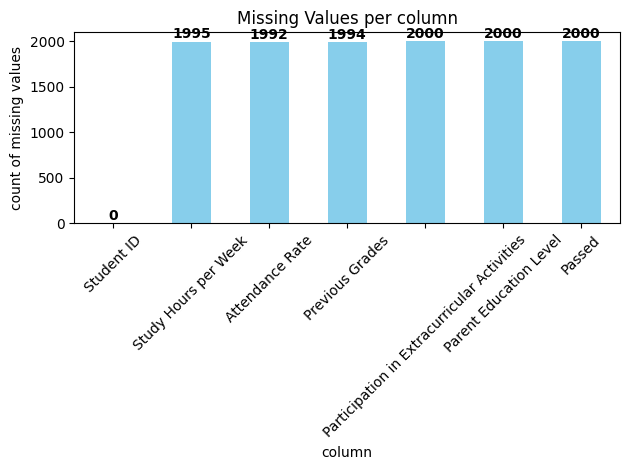

In [32]:
ax=missing.plot(kind='bar',color='skyblue')
plt.title('Missing Values per column')
plt.ylabel('count of missing values')
plt.xlabel('column')
plt.xticks(rotation=45)


for index,value in enumerate(missing):
    plt.text(index,value+5,str(value),ha='center',va='bottom',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
df['Study Hours per Week'] = df['Study Hours per Week'].fillna( df['Study Hours per Week'].median()  )
df['Attendance Rate'] = df['Attendance Rate'].fillna( df['Attendance Rate'].median() )
df['Previous Grades'] = df['Previous Grades'].fillna( df['Previous Grades'].median() )
df

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,75.3,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,75.3,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No
...,...,...,...,...,...,...,...
39995,S39996,15.6,93.8,51.4,Yes,Master,No
39996,S39997,11.3,66.4,64.2,No,Doctorate,Yes
39997,S39998,13.1,65.6,38.1,No,Bachelor,No
39998,S39999,14.1,74.9,65.2,Yes,Master,No


In [34]:
df['Study Hours per Week'].describe()

count    40000.000000
mean         9.964602
std          4.904088
min        -12.300000
25%          6.800000
50%         10.000000
75%         13.200000
max         32.400000
Name: Study Hours per Week, dtype: float64

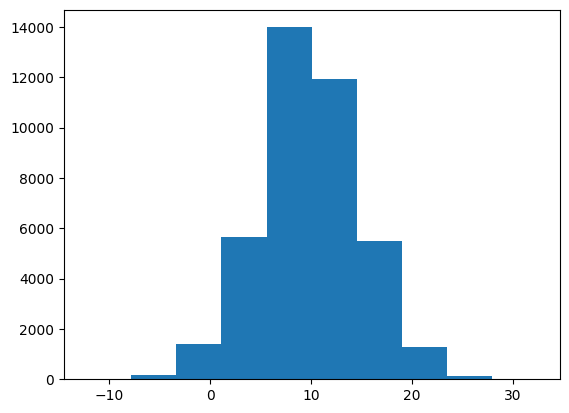

In [35]:
plt.hist( df['Study Hours per Week'] )
plt.show()

In [36]:
df.isnull().sum()

Student ID                                        0
Study Hours per Week                              0
Attendance Rate                                   0
Previous Grades                                   0
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_1464\4117705914.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Passed',data=df,palette='pastel')


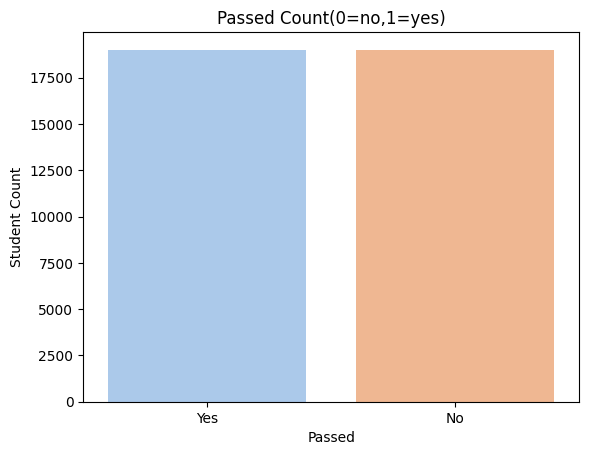

In [37]:
sns.countplot(x='Passed',data=df,palette='pastel')
plt.title('Passed Count(0=no,1=yes)')
plt.xlabel('Passed')
plt.ylabel('Student Count')
plt.show()



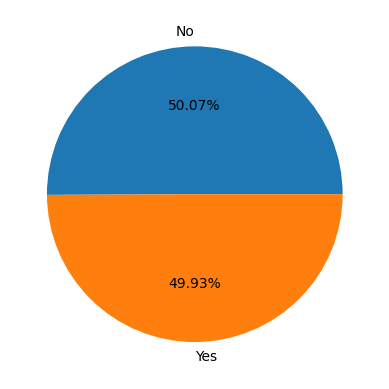

In [38]:
df['Participation in Extracurricular Activities'].value_counts().plot(kind='pie' , autopct='%.2f%%')
plt.show()

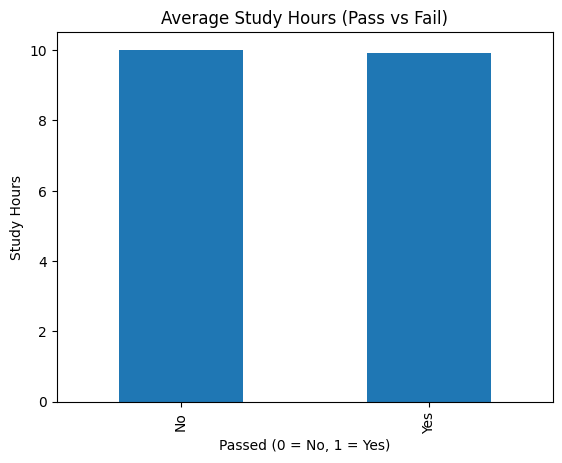

In [39]:
df.groupby('Passed')['Study Hours per Week'].mean().plot(kind='bar')
plt.title("Average Study Hours (Pass vs Fail)")
plt.xlabel("Passed (0 = No, 1 = Yes)")
plt.ylabel("Study Hours")
plt.show()

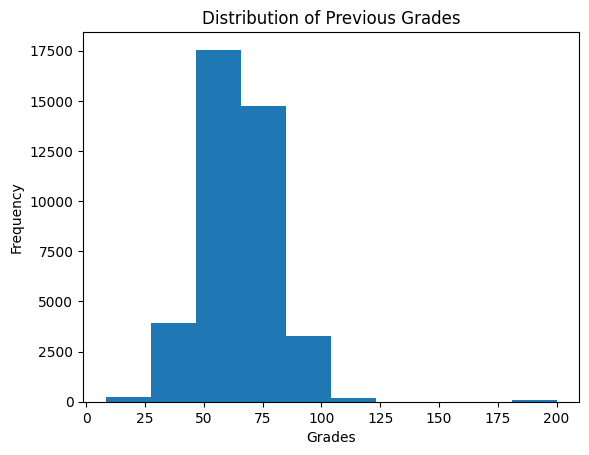

In [40]:
plt.hist(df['Previous Grades'], bins=10)
plt.title("Distribution of Previous Grades")
plt.xlabel("Grades")
plt.ylabel("Frequency")
plt.show()

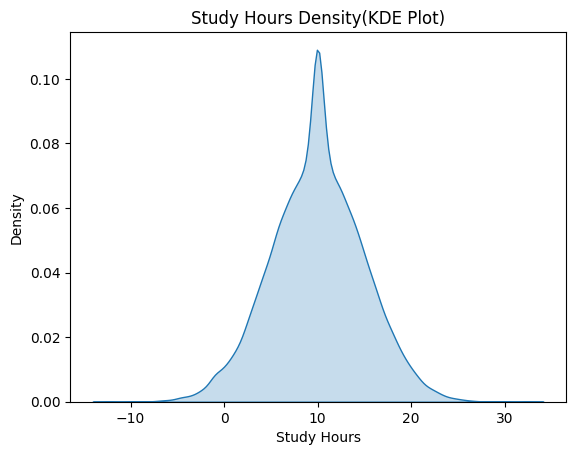

In [41]:
sns.kdeplot(df['Study Hours per Week'],fill=True)
plt.title("Study Hours Density(KDE Plot)")
plt.xlabel("Study Hours")
plt.ylabel("Density")
plt.show()

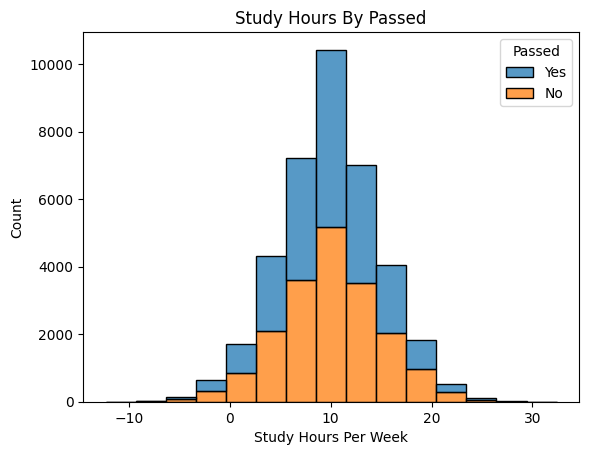

In [42]:
sns.histplot(data=df,x='Study Hours per Week',hue='Passed',multiple='stack',bins=15)
plt.title("Study Hours By Passed")
plt.xlabel("Study Hours Per Week")
plt.ylabel("Count")
plt.show()